### 🤖 LLM and AI Agent Development Courses  
**✨ All courses available for just ₹399 INR / $9.99 USD ✨**

| Course | Description | Enroll |
|--------|-------------|---------|
| **🎯 Master OpenAI Agent Builder** | Build and deploy AI agents visually using OpenAI Agent Builder, ChatKit, RAG, Chatbot, AI Assistant with MCP, AWS, RDS MySQL | [Enroll Now](https://kgptalkie.com/agent-builder) |
| **🔥 MCP Mastery** | Build MCP servers & clients with Python, Streamlit, ChromaDB, LangChain, LangGraph agents, and Ollama integrations | [Enroll Now](https://kgptalkie.com/mcp) |
| **📊 Private Agentic RAG with LangChain** | Step-by-Step Guide to RAG with LangChain v1, LangGraph, and Ollama (Qwen3, Gemma3, DeepSeek-R1, LLAMA, FAISS) | [Enroll Now](https://kgptalkie.com/agentic-rag) |
| **🔧 Master LangGraph and LangChain** | Agentic RAG and Chatbot, AI Agent with LangChain v1, Qwen3, Gemma3, DeepSeek-R1, LLAMA 3.2, FAISS Vector Database | [Enroll Now](https://kgptalkie.com/langgraph) |
| **⚡ Master Langchain and Ollama** | Master Langchain v1, Local LLM Projects with Ollama, Qwen3, Gemma3, DeepSeek-R1, LLAMA 3.2, Complete Integration Guide | [Enroll Now](https://kgptalkie.com/langchain) |
| **🔬 Fine Tuning LLM** | Learn transformer architecture fundamentals and fine-tune LLMs with custom datasets | [Enroll Now](https://kgptalkie.com/fine-tuning-llm) |

---

### 🌐 Join the Community & Stay Connected

- 🔗 **Join the Discord Community:** https://discord.gg/RFjwbkNa  
- 📺 **Subscribe on YouTube (63K+ learners):** http://www.youtube.com/@KGPTalkie

---


## Agentic RAG with Langchain v1, Ollama, and FAISS
**Key Features:**
- Agent-based architecture with autonomous tool usage for document retrieval
- FAISS vector store for efficient semantic search across document embeddings
- Ollama integration with Qwen3 LLM and nomic-embed-text embeddings for local deployment
- Custom retrieval tool that finds and formats relevant document chunks with metadata
- Interactive chat interface with streaming responses and tool call visibility

In [ ]:
# pip install -U langchain langchain-ollama, langchain-community langchain-core faiss-cpu
# ollama pull nomic-embed-text
# ollama pull qwen3

In [1]:
import os
import warnings
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
warnings.filterwarnings("ignore")

from langchain_core.tools import tool
from langchain.agents import create_agent
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_community.vectorstores import FAISS
from dotenv import load_dotenv


load_dotenv()

True

In [3]:
# ============================================================================
# LLM & VECTOR STORE SETUP
# ============================================================================
# Ollama LLM with Qwen3
llm = ChatOllama(
    model="qwen3", 
    base_url="http://localhost:11434"
)

# Ollama Embeddings
embeddings = OllamaEmbeddings(
    model="nomic-embed-text",
    base_url="http://localhost:11434"
)

# FAISS Vector Store (assumes data already exists from previous code)
db_name = "./../09b. Agentic RAG with Langchain V1/health_supplements"
vector_store = FAISS.load_local(
    db_name,
    embeddings,
    allow_dangerous_deserialization=True
)

In [4]:
llm.invoke("Hello")

AIMessage(content='Hello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'model': 'qwen3', 'created_at': '2025-12-22T18:51:13.345125Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4446212292, 'load_duration': 885596875, 'prompt_eval_count': 11, 'prompt_eval_duration': 324834500, 'eval_count': 111, 'eval_duration': 3181620261, 'logprobs': None, 'model_name': 'qwen3', 'model_provider': 'ollama'}, id='lc_run--019b4766-a89c-7a80-b02c-3eca4f77b2c5-0', usage_metadata={'input_tokens': 11, 'output_tokens': 111, 'total_tokens': 122})

In [5]:
# ============================================================================
# VECTOR STORE VERIFICATION
# ============================================================================
print("\n🔍 Testing Vector Store Connection...")

# Test 1: Check collection info
doc_count = vector_store.index.ntotal
print(f"✓ Vector store found with {doc_count} documents")


# Test 2: Sample similarity search
test_query = "creatine"
results = vector_store.similarity_search(test_query, k=3)
print(f"\n✓ Sample search for '{test_query}':")
for i, doc in enumerate(results, 1):
    print(f"  {i}. Source: {doc.metadata.get('source', '?')} (Page {doc.metadata.get('page', '?')}): {doc.page_content[:100]}...")




🔍 Testing Vector Store Connection...
✓ Vector store found with 201 documents

✓ Sample search for 'creatine':
  1. Source: rag-dataset/health supplements/2. Nutraceuticals research.pdf (Page 9): its bioactive component monacolin K allowed it to be used
for people with moderate dyslipidaemia.
Mo...
  2. Source: rag-dataset/health supplements/3.health_supplements_side_effects.pdf (Page 6): of both ephedrine and amphetamine” (70). It has sympathomimetic and vasoconstrictive 
properties. Pr...
  3. Source: rag-dataset/health supplements/1. dietary supplements - for whom.pdf (Page 14): yohimbine, and even amphetamine and its derivatives being found in supplements con-
tinues to grow [...


In [6]:
results

[Document(id='9354accc-8929-4d37-8403-a9be45a2fd62', metadata={'producer': 'iLovePDF', 'creator': '', 'creationdate': '', 'source': 'rag-dataset/health supplements/2. Nutraceuticals research.pdf', 'file_path': 'rag-dataset/health supplements/2. Nutraceuticals research.pdf', 'total_pages': 10, 'format': 'PDF 1.4', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2024-10-21T11:38:30+00:00', 'trapped': '', 'modDate': 'D:20241021113830Z', 'creationDate': '', 'page': 9}, page_content='its bioactive component monacolin K allowed it to be used\nfor people with moderate dyslipidaemia.\nMonacolin K (chemically identical to lovastatin, a drug\nused to control hypercholesterolaemia), which has been\nrecognized as a key component in cholesterol reduction,\nhas been validated as the source of its hypocholesterolaemic\neffect. A recent study on the safety proﬁle of RYR conducted\nwithin the Italian Surveillance System of Natural Health\nProducts\non\npossible\nunwanted\nside\nef

In [7]:
# ============================================================================
# RETRIEVAL TOOL
# ============================================================================
@tool()
def retrieve_context(query: str):
    """Retrieve relevant information for health related queries from the document to answer the query.
    
    """
    print(f"🔍 Searching: '{query}'")
    
    # Perform similarity search
    docs = vector_store.similarity_search(query, k=4)
    
    # Format for LLM
    content = "\n\n".join(
        f"Source: {doc.metadata.get('source', '?')} (Page {doc.metadata.get('page', '?')}): {doc.page_content}"
        for doc in docs
    )
    
    print(f"✓ Found {len(docs)} relevant chunks")
    return content


In [8]:
result = retrieve_context.invoke("What is the use of BCAA?")
print(result)

🔍 Searching: 'What is the use of BCAA?'
✓ Found 4 relevant chunks
Source: rag-dataset/health supplements/3.health_supplements_side_effects.pdf (Page 1): Author Manuscript
Author Manuscript
Author Manuscript
Author Manuscript

Source: rag-dataset/health supplements/2. Nutraceuticals research.pdf (Page 1): Introduction
There is a growing overlap between conventional food
(including beverages) and food supplements, including
energy bars and teas or liquids. This overlap becomes even
wider when we consider functional foods and nutraceuticals.
What could be considered a functional food under a given set
of circumstances may be named a dietary supplement,
medical food, food for special dietary use or nutraceutical
under different circumstances, depending on its ingredients
(active components) and the claims reported on its label [1].
While the deﬁnition of a food supplement is quite clear
and understandable (see Table 1), the deﬁnition of a
nutraceutical is still in the grey area between foo

#### Create Tools and Agent

In [9]:
tools = [retrieve_context]

system_prompt = """You are a research assistant with a document retrieval tool.

                    Tool:
                    - retrieve_context: Search the document for the health related question

                    Cite page numbers and reference document while writing the answer and be thorough."""

In [10]:
# Create the agentic RAG
rag_agent = create_agent(llm, tools, system_prompt=system_prompt)

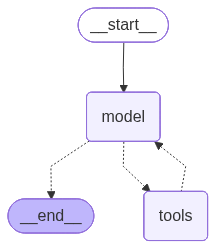

In [11]:
rag_agent

In [12]:
result = rag_agent.invoke({'messages': "What is the use of BCAA?"})

🔍 Searching: 'use of BCAA'
✓ Found 4 relevant chunks


In [13]:
result

{'messages': [HumanMessage(content='What is the use of BCAA?', additional_kwargs={}, response_metadata={}, id='5ddd9ba2-4bb7-444f-a8aa-a73a916ec6a1'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3', 'created_at': '2025-12-22T18:52:51.693582Z', 'done': True, 'done_reason': 'stop', 'total_duration': 7228982750, 'load_duration': 103488583, 'prompt_eval_count': 196, 'prompt_eval_duration': 708054083, 'eval_count': 221, 'eval_duration': 6347824668, 'logprobs': None, 'model_name': 'qwen3', 'model_provider': 'ollama'}, id='lc_run--019b4768-1e2e-79c3-ba8d-7d2ca617dcfb-0', tool_calls=[{'name': 'retrieve_context', 'args': {'query': 'use of BCAA'}, 'id': '91429d08-9aa0-457f-b8ff-b65e599bd16e', 'type': 'tool_call'}], usage_metadata={'input_tokens': 196, 'output_tokens': 221, 'total_tokens': 417}),
  ToolMessage(content='Source: rag-dataset/health supplements/3.health_supplements_side_effects.pdf (Page 1): Author Manuscript\nAuthor Manuscript\nAuthor Manuscript\nA

In [14]:
result['messages'][-1].pretty_print()

================================== Ai Message ==================================

The provided documents do not contain specific information about the use of Branched-Chain Amino Acids (BCAA). The retrieved sources discuss topics such as adverse effects of supplements like OxyELITE Pro, definitions of nutraceuticals, and regulatory frameworks for dietary supplements, but none address BCAA's applications. For detailed information on BCAA, consult specialized nutritional resources or scientific literature. 

**References:**  
- The retrieved documents focus on supplement safety and definitions rather than BCAA-specific uses.


In [15]:
# ============================================================================
# QUERY FUNCTION
# ============================================================================
def ask(question: str):
    """Ask the agentic RAG a question."""
    print(f"\n{'='*60}")
    print(f"Question: {question}")
    print('='*60)
    
    for event in rag_agent.stream(
        {"messages": [{"role": "user", "content": question}]},
        stream_mode="values"
    ):
        msg = event["messages"][-1]
        
        # Show tool usage
        if hasattr(msg, 'tool_calls') and msg.tool_calls:
            for tc in msg.tool_calls:
                print("Tool Call: ")
                print(f"\n🔧 Using: {tc['name']} with {tc['args']}")
        
        # Show final answer
        elif hasattr(msg, 'content') and msg.content:
            print(f"\n💬 Answer:\n{msg.content}")

In [16]:
# ============================================================================
# TESTING
# ============================================================================
# Test basic retrieval
ask("how to gain muscle mass?")



Question: how to gain muscle mass?

💬 Answer:
how to gain muscle mass?
Tool Call: 

🔧 Using: retrieve_context with {'query': 'how to gain muscle mass'}
🔍 Searching: 'how to gain muscle mass'
✓ Found 4 relevant chunks

💬 Answer:
Source: rag-dataset/health supplements/1. dietary supplements - for whom.pdf (Page 12): Int. J. Environ. Res. Public Health 2021, 18, 8897
13 of 24
3.3. Dietary Supplements and Weight Loss
The number of people with excessive weight continues to rise, and ﬁghting obesity
has become one of the greatest challenges of contemporary medicine. A person wishing to
lose weight needs to undertake several difﬁcult life-changes and practice them consistently
(diet, physical activity, addiction-free). Meanwhile dietary supplements are presented as
a compelling alternative to traditional methods for combatting obesity. Wróbel-Harmas
et al. [107] demonstrated that weight loss supplements are the most frequently sought di-
etary supplements on the Internet, followed by prepara

In [17]:
ask("tell me 3 facts about Earth?")


Question: tell me 3 facts about Earth?

💬 Answer:
tell me 3 facts about Earth?

💬 Answer:
The query about Earth is not related to health, so the provided tool (retrieve_context) cannot be used. Here are three general facts about Earth:

1. **Unique in the Solar System**: Earth is the only known planet that supports life, with liquid water, a breathable atmosphere, and stable temperatures.  
2. **Dynamic Geology**: It has active volcanoes, tectonic plates, and a magnetic field generated by its molten iron core.  
3. **Biodiversity**: Over 8 million species inhabit Earth, from microscopic organisms to large mammals, thriving in diverse ecosystems.  

These facts are based on general scientific knowledge. Let me know if you'd like health-related information!


In [ ]:
# ============================================================================
# INTERACTIVE CHAT
# ============================================================================
def chat():
    """Start interactive chat with the agentic RAG."""
    print("\n🤖 Agentic RAG Chat - Type 'quit, q or exit' to exit")
    
    while True:
        question = input("\nYour question: ").strip()
        if question.lower() in ['quit', 'exit', 'q']:
            break
        if question:
            ask(question)

chat()


🤖 Agentic RAG Chat - Type 'quit, q or exit' to exit
